Q1 (4 marks)

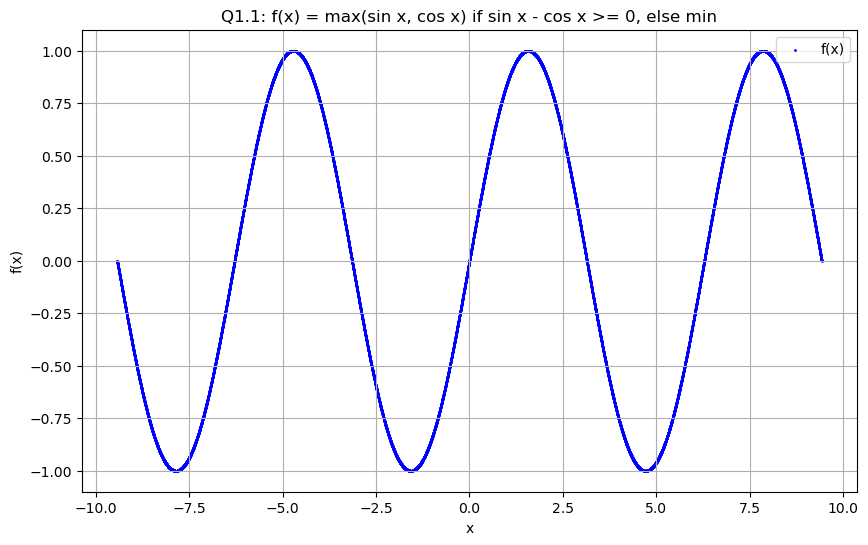

C:\Users\12546\AppData\Local\Temp\ipykernel_24552\2251454494.py:46: RuntimeWarning: divide by zero encountered in divide
  np.cos(1 / x_safe)))
C:\Users\12546\AppData\Local\Temp\ipykernel_24552\2251454494.py:46: RuntimeWarning: invalid value encountered in cos
  np.cos(1 / x_safe)))


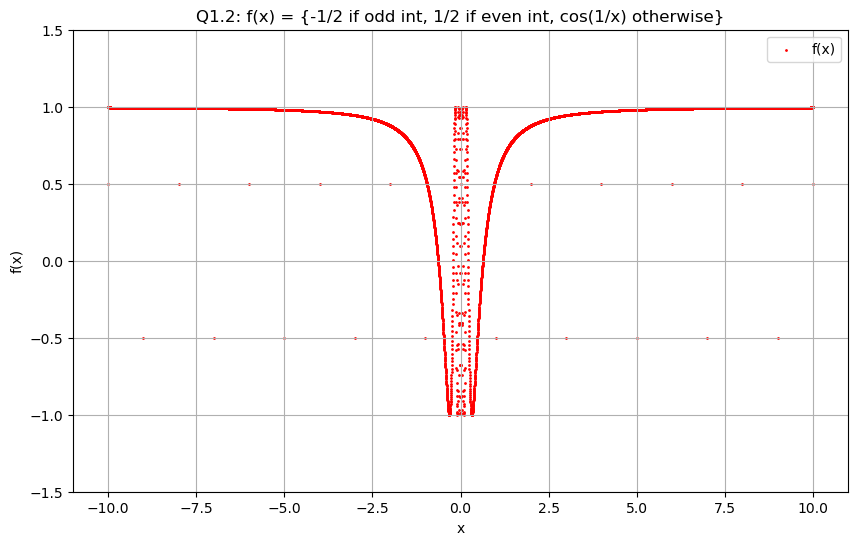

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Q1.1
# Generate >10000 points in [-3π, 3π]
x = np.linspace(-3 * np.pi, 3 * np.pi, 10001)
sin_x = np.sin(x)
cos_x = np.cos(x)

# Use broadcasting and np.where to avoid loops and if-else
condition = sin_x - cos_x >= 0
y = np.where(condition, np.maximum(sin_x, cos_x), np.minimum(sin_x, cos_x))

# Plot scatter
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=1, color='blue', label='f(x)')
plt.title('Q1.1: f(x) = max(sin x, cos x) if sin x - cos x >= 0, else min')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()


#%% Q1.2
import numpy as np
import matplotlib.pyplot as plt

# Generate >10000 points in [-10, 10]
x = np.linspace(-10, 10, 10001)

# Avoid division by zero: set very small epsilon for x near 0
epsilon = 1e-8
x_safe = np.where(np.abs(x) < epsilon, np.sign(x) * epsilon, x)

# Check if x is integer (within floating point tolerance)
is_integer = np.abs(x - np.round(x)) < 1e-8

# For integer points: check even/odd
is_even = np.logical_and(is_integer, np.round(x) % 2 == 0)
is_odd = np.logical_and(is_integer, np.round(x) % 2 == 1)

# Compute y using broadcasting and np.where
y = np.where(is_even, 0.5,
             np.where(is_odd, -0.5,
                      np.cos(1 / x_safe)))

# Plot scatter
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=1, color='red', label='f(x)')
plt.title('Q1.2: f(x) = {-1/2 if odd int, 1/2 if even int, cos(1/x) otherwise}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.ylim(-1.5, 1.5)  # Optional: limit y-axis for better view
plt.show()

Q2 (4 marks)

In [2]:

def H(*args):
    """
    Compute the Hessian matrix of f(x1, x2, ..., xn) = exp(sum(xi^2))
    Input: variable number of arguments (x1, x2, ..., xn)
    Output: n x n NumPy array (Hessian matrix)
    Uses broadcasting only. No loops or if-else.
    """
    # Convert args to a 1D NumPy array
    x = np.array(args)  # shape: (n,)
    n = len(x)

    # Compute f(x) = exp(sum(xi^2))
    f_val = np.exp(np.sum(x**2))

    # Compute outer product: x ⊗ x → shape (n, n)
    outer_product = x[:, None] * x[None, :]  # Broadcasting: column vector * row vector

    # Compute identity matrix I (n x n)
    identity = np.eye(n)

    # Hessian = f(x) * (4 * outer_product + 2 * identity)
    hessian = f_val * (4 * outer_product + 2 * identity)

    return hessian


if __name__ == "__main__":
    # Test with 2 variables
    print("Hessian for H(x1, x2):")
    print(H(1, 2))
    print()

    # Test with 3 variables
    print("Hessian for H(x1, x2, x3):")
    print(H(1, 2, 3))
    print()

    # Test with 1 variable
    print("Hessian for H(x1):")
    print(H(5))

Hessian for H(x1, x2):
[[ 890.47895462 1187.30527282]
 [1187.30527282 2671.43686385]]

Hessian for H(x1, x2, x3):
[[ 7215625.70498866  9620834.27331821 14431251.40997732]
 [ 9620834.27331821 21646877.11496598 28862502.81995464]
 [14431251.40997732 28862502.81995464 45698962.79826152]]

Hessian for H(x1):
[[7.34449973e+12]]


Q3
(Part a, 3 marks)
(Part b, 3 marks)

In [13]:
import numpy as np

# part(a)

np.random.seed(3042)  

# Define grid: 0.01 step from 0 to 10 (inclusive)
x_grid = np.arange(0, 10.01, 0.01)  # 1001 points
y_grid = np.arange(0, 10.01, 0.01)  # 1001 points
X, Y = np.meshgrid(x_grid, y_grid, indexing='ij')  # X,Y shape: (1001, 1001)
points = np.stack([X.ravel(), Y.ravel()], axis=1)  # shape: (1002001, 2)

# Generate 5 random circle centers in [0,10]x[0,10]
centers = np.random.uniform(0, 10, size=(5, 2))  # shape: (5, 2)
radius = 2.0

# Compute distance from each point to each center
# points: (N, 2), centers: (5, 2) -> broadcast to (N, 5, 2)
diff = points[:, None, :] - centers[None, :, :]  # shape: (N, 5, 2)
distances = np.sqrt(np.sum(diff**2, axis=2))  # shape: (N, 5)

# Check if point is inside at least one circle
inside_any_circle = np.any(distances <= radius, axis=1)  # shape: (N,)

# Count points inside and compute area
count_inside = np.sum(inside_any_circle)
area = count_inside * (0.01 * 0.01)

print(f"Part(a): Total area covered by 5 random circles (radius 2) within 10x10 grid: {area:.6f} unit²")
print(f"Number of grid points inside circles: {count_inside}")


# part(b)
import numpy as np

# Generate 5 random square centers and rotation angles
centers = np.random.uniform(0, 10, size=(5, 2))  # shape: (5, 2)
angles = np.random.uniform(0, 2*np.pi, size=5)   # shape: (5,)

side_length = 3.0
half_side = side_length / 2  # 1.5

# For each square, we need to check if a point is inside it after inverse rotation
# We'll compute for all points and all squares simultaneously using broadcasting

# Expand points to (N, 5, 2) and centers to (1, 5, 2)
points_expanded = points[:, None, :]  # shape: (N, 1, 2) -> will broadcast to (N, 5, 2)
centers_expanded = centers[None, :, :]  # shape: (1, 5, 2)

# Translate points relative to centers
translated = points_expanded - centers_expanded  # shape: (N, 5, 2)

# Create rotation matrices for inverse rotation (-angle)
cos_ang = np.cos(-angles)  # shape: (5,)
sin_ang = np.sin(-angles)  # shape: (5,)

# Apply rotation: [x', y'] = [x*cosθ + y*sinθ, -x*sinθ + y*cosθ]
x_prime = translated[:, :, 0] * cos_ang[None, :] + translated[:, :, 1] * sin_ang[None, :]
y_prime = -translated[:, :, 0] * sin_ang[None, :] + translated[:, :, 1] * cos_ang[None, :]

# Check if point is inside square: |x'| <= half_side and |y'| <= half_side
inside_square = (np.abs(x_prime) <= half_side) & (np.abs(y_prime) <= half_side)  # shape: (N, 5)

# Check if point is inside at least one square
inside_any_square = np.any(inside_square, axis=1)  # shape: (N,)

# Count points inside and compute area
count_inside = np.sum(inside_any_square)
area = count_inside * (0.01 * 0.01)

print(f"Part(b): Total area covered by 5 random rotated squares (side 3) within 10x10 grid: {area:.6f} unit²")
print(f"Number of grid points inside squares: {count_inside}")

Part(a): Total area covered by 5 random circles (radius 2) within 10x10 grid: 49.457900 unit²
Number of grid points inside circles: 494579
Part(b): Total area covered by 5 random rotated squares (side 3) within 10x10 grid: 32.118900 unit²
Number of grid points inside squares: 321189


Q4
(Part a, 3 marks)
(Part b, 3 marks)

--- Running Part A Simulation (Base Model)... ---
Part A Optimal Frequency: Day 208
Part A Corresponding Yield per Day: 758.8413

--- Running Part B Simulation (With Inhibition)... ---
Part B Optimal Frequency: Day 211
Part B Corresponding Yield per Day: 712.6161


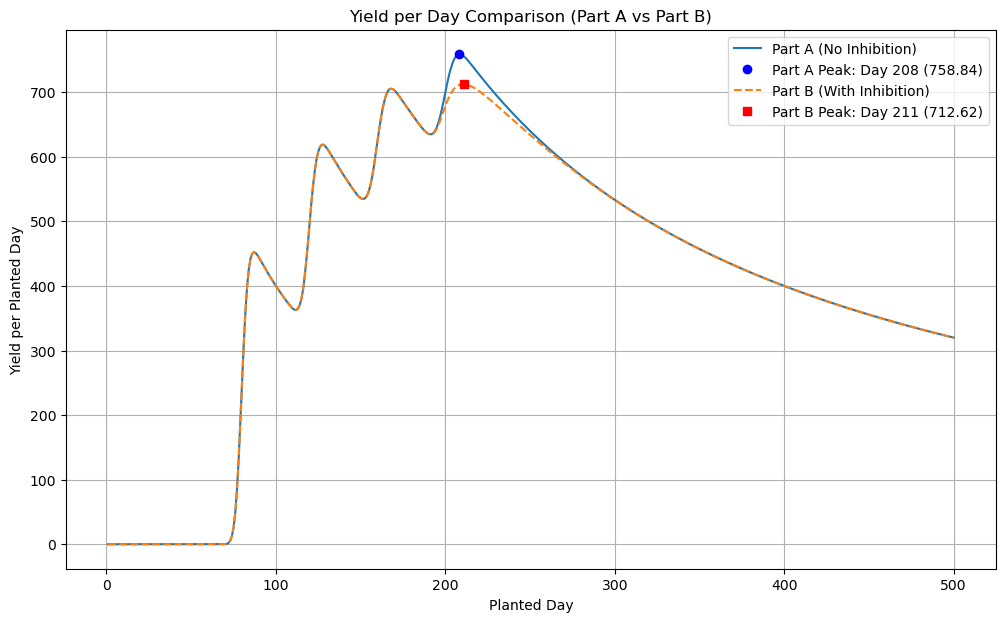

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import warnings

# Ignore runtime warnings (e.g., division by zero) when calculating yield_per_day
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in divide")

def calculate_fruits(field_heights):
    """
    Calculates the total number of fruits based on the field height matrix.
    Rule: Fruits = floor(height) - 1, for height >= 2
    """
    fruit_per_crop = np.maximum(0, np.floor(field_heights) - 1)
    return np.sum(fruit_per_crop)

def analyze_yield_frequency(daily_total_yields):
    """
    Calculates the 'yield per planted day' from a list of cumulative daily yields.
    """
    days = np.arange(1, len(daily_total_yields) + 1)
    
    # The metric is total yield divided by the number of days waited
    yield_per_day = np.array(daily_total_yields) / days
    
    # Find the optimal day
    optimal_day_index = np.nanargmax(yield_per_day)
    optimal_day = optimal_day_index + 1  # Convert to 1-based day
    max_yield_per_day = yield_per_day[optimal_day_index]
    
    return days, yield_per_day, optimal_day, max_yield_per_day

#part(a)
def simulate_part_a(grid_size=200, max_days=500, seed=42):
    """
    Simulates Part A: Base growth model.
    """
    print("--- Running Part A Simulation (Base Model)... ---")
    
    # Set random seed for reproducibility
    np.random.seed(seed)
    
    field_heights = np.zeros((grid_size, grid_size))
    # 'growing_mask' tracks which crops are still growing
    growing_mask = np.ones((grid_size, grid_size), dtype=bool)
    
    daily_total_yields = []

    for day in range(max_days):
        growth = np.random.uniform(0.01, 0.04, (grid_size, grid_size))
        
        field_heights[growing_mask] += growth[growing_mask]
        
        stopped_growing_mask = (field_heights >= 5.0)
        
        field_heights[stopped_growing_mask] = 5.0
        growing_mask[stopped_growing_mask] = False
        
        total_fruit = calculate_fruits(field_heights)
        daily_total_yields.append(total_fruit)

    days, ypd, opt_day, max_ypd = analyze_yield_frequency(daily_total_yields)

    print(f"Part A Optimal Frequency: Day {opt_day}")
    print(f"Part A Corresponding Yield per Day: {max_ypd:.4f}")
    
    return days, ypd, opt_day, max_ypd

# part(b)
def simulate_part_b(grid_size=200, max_days=500, seed=42):
    """
    Simulates Part B: Growth model with inhibition (using convolution).
    """
    print("\n--- Running Part B Simulation (With Inhibition)... ---")
    
    # Set random seed for reproducibility
    np.random.seed(seed)
    
    field_heights = np.zeros((grid_size, grid_size))
    growing_mask = np.ones((grid_size, grid_size), dtype=bool)
    
    daily_total_yields = []
    
    # Define the convolution kernel for 8 neighbors
    # [[1, 1, 1],
    #  [1, 0, 1],  <-- 0 means not counting self
    #  [1, 1, 1]]
    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]])

    for day in range(max_days):
        base_growth = np.random.uniform(0.01, 0.04, (grid_size, grid_size))
        
        # --- Key change for Part B starts here ---
        is_5_tall = (field_heights >= 5.0).astype(int)
        
        neighbor_count = convolve2d(is_5_tall, kernel, 
                                    mode='same',     # Keep output size the same
                                    boundary='fill', # Treat edges as 0
                                    fillvalue=0)
        
        growth_multiplier = 1.0 - (neighbor_count / 9.0)
        
        applied_growth = base_growth * growth_multiplier
        # --- Key change for Part B ends here ---
        
        field_heights[growing_mask] += applied_growth[growing_mask]
        
        stopped_growing_mask = (field_heights >= 5.0)
        
        field_heights[stopped_growing_mask] = 5.0
        growing_mask[stopped_growing_mask] = False
        
        total_fruit = calculate_fruits(field_heights)
        daily_total_yields.append(total_fruit)

    days, ypd, opt_day, max_ypd = analyze_yield_frequency(daily_total_yields)

    print(f"Part B Optimal Frequency: Day {opt_day}")
    print(f"Part B Corresponding Yield per Day: {max_ypd:.4f}")
    
    return days, ypd, opt_day, max_ypd

def plot_comparison(results_a, results_b):
    """
    Plots the comparison between Part A and Part B results.
    """
    days_a, ypd_a, opt_day_a, max_ypd_a = results_a
    days_b, ypd_b, opt_day_b, max_ypd_b = results_b
    
    plt.figure(figsize=(12, 7))
    
    # Plot Part A
    plt.plot(days_a, ypd_a, label=f'Part A (No Inhibition)')
    plt.plot(opt_day_a, max_ypd_a, 'o', color='blue', 
             label=f'Part A Peak: Day {opt_day_a} ({max_ypd_a:.2f})')
    
    # Plot Part B
    plt.plot(days_b, ypd_b, label=f'Part B (With Inhibition)', linestyle='--')
    plt.plot(opt_day_b, max_ypd_b, 's', color='red', 
             label=f'Part B Peak: Day {opt_day_b} ({max_ypd_b:.2f})')
    
    plt.title('Yield per Day Comparison (Part A vs Part B)')
    plt.xlabel('Planted Day')
    plt.ylabel('Yield per Planted Day')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Main execution ---
if __name__ == "__main__":
    
    GRID_SIZE = 200
    MAX_DAYS = 500
    RANDOM_SEED = 3042  # Use fixed seed for reproducible results
    
    results_a = simulate_part_a(GRID_SIZE, MAX_DAYS, RANDOM_SEED)
    results_b = simulate_part_b(GRID_SIZE, MAX_DAYS, RANDOM_SEED)
    
    plot_comparison(results_a, results_b)